# 🌾 Crop Recommendation System
### Predictive Analytics — Group Project
| | |
|---|---|
| **Members** | Adithyan · Abhitha |
| **Dataset** | Crop Recommendation Dataset (Kaggle) |
| **Models** | Random Forest · KNN · Decision Tree |
| **Deployment** | Streamlit Community Cloud |
---


## ⚙️ Colab Setup — Run This First!

In [15]:
# Run this cell first every time you open this notebook in Colab
!pip install shap -q

import os
os.makedirs('models', exist_ok=True)
os.makedirs('data', exist_ok=True)

print("✅ Setup complete!")


✅ Setup complete!


---
## Stage 1 — Problem Definition & Literature Review
**Lead: Adithyan** | Issue #1

### 1.1 Problem Statement
Agriculture is the backbone of India's economy, yet farmers often lack access to data-driven guidance on which crop to grow for a given set of soil and climate conditions. Choosing the wrong crop leads to poor yield, financial loss, and inefficient use of resources like water and fertiliser.

This project builds a **multi-class crop recommendation system** that predicts the most suitable crop to grow based on seven measurable soil and climate parameters:
- **Soil nutrients**: Nitrogen (N), Phosphorus (P), Potassium (K)
- **Climate**: Temperature (°C), Humidity (%), Rainfall (mm)
- **Soil chemistry**: pH value

### 1.2 Objectives
1. Build and compare three multi-class classifiers: **Random Forest**, **K-Nearest Neighbours (KNN)**, and **Decision Tree**
2. Identify the most influential features driving crop selection using feature importance
3. Explain model predictions using SHAP values for interpretability
4. Deploy an interactive web application accessible to farmers via Streamlit

### 1.3 Literature Review
| Reference | Key Finding | Relevance |
|---|---|---|
| Doshi et al. (2018) | Random Forest outperformed SVM and Naïve Bayes for crop prediction | Justifies RF as primary model |
| Pudumalar et al. (2017) | Ensemble methods improve accuracy on agricultural datasets | Supports multi-model approach |
| Mucherino et al. (2009) | KNN effective for small, balanced agricultural datasets | Justifies KNN inclusion |
| Lundberg & Lee (2017) | SHAP provides consistent, locally accurate feature attributions | Justifies explainability approach |

### 1.4 Motivation
Precision agriculture tools are increasingly accessible via mobile devices in rural India. A lightweight, interpretable ML model deployed as a web app bridges the gap between data science and farming practice.
---


---
## Stage 2 — Data Collection & Data Understanding
**Lead: Abhitha** | Issue #2


In [16]:
# ── 2.1 Imports ─────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print("✅ Libraries loaded successfully")


✅ Libraries loaded successfully


In [17]:
# ── 2.2 Load Dataset ────────────────────────────────────────────────────
df = pd.read_csv('/content/Crop_recommendation dataset.csv')

print("=" * 50)
print(f"Dataset shape   : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Features        : {df.columns[:-1].tolist()}")
print(f"Target column   : '{df.columns[-1]}'")
print(f"Number of crops : {df['label'].nunique()}")
print("=" * 50)
df.head(10)


Dataset shape   : 2200 rows × 8 columns
Features        : ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
Target column   : 'label'
Number of crops : 22


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
5,69,37,42,23.058049,83.370118,7.073454,251.055000,rice
6,69,55,38,22.708838,82.639414,5.700806,271.324860,rice
7,94,53,40,20.277744,82.894086,5.718627,241.974195,rice
8,89,54,38,24.515881,83.535216,6.685346,230.446236,rice
9,68,58,38,23.223974,83.033227,6.336254,221.209196,rice


In [18]:
# ── 2.3 Dataset Info ────────────────────────────────────────────────────
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [19]:
# ── 2.4 Feature Descriptions ────────────────────────────────────────────
feature_info = pd.DataFrame({
    'Feature'  : ['N','P','K','temperature','humidity','ph','rainfall','label'],
    'Full Name': ['Nitrogen','Phosphorus','Potassium','Temperature',
                  'Humidity','pH Value','Rainfall','Crop Label'],
    'Unit'     : ['kg/ha','kg/ha','kg/ha','°C','%','pH scale (0-14)','mm','Categorical'],
    'Type'     : ['Integer','Integer','Integer','Float','Float','Float','Float','String']
})
print(feature_info.to_string(index=False))


    Feature   Full Name            Unit    Type
          N    Nitrogen           kg/ha Integer
          P  Phosphorus           kg/ha Integer
          K   Potassium           kg/ha Integer
temperature Temperature              °C   Float
   humidity    Humidity               %   Float
         ph    pH Value pH scale (0-14)   Float
   rainfall    Rainfall              mm   Float
      label  Crop Label     Categorical  String


In [20]:
# ── 2.5 All 22 Crop Classes ─────────────────────────────────────────────
crops = sorted(df['label'].unique())
print(f"All {len(crops)} crops in the dataset:")
for i, crop in enumerate(crops, 1):
    print(f"  {i:2d}. {crop}")


All 22 crops in the dataset:
   1. apple
   2. banana
   3. blackgram
   4. chickpea
   5. coconut
   6. coffee
   7. cotton
   8. grapes
   9. jute
  10. kidneybeans
  11. lentil
  12. maize
  13. mango
  14. mothbeans
  15. mungbean
  16. muskmelon
  17. orange
  18. papaya
  19. pigeonpeas
  20. pomegranate
  21. rice
  22. watermelon


In [21]:
# ── 2.6 Statistical Summary ─────────────────────────────────────────────
df.describe().round(2)


,N,P,K,temperature,humidity,ph,rainfall
count,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00
mean,50.55,53.36,48.15,25.62,71.48,6.47,103.46
std,36.92,32.99,50.65,5.06,22.26,0.77,54.96
min,0.00,5.00,5.00,8.83,14.26,3.50,20.21
25%,21.00,28.00,20.00,22.77,60.26,5.97,64.55
50%,37.00,51.00,32.00,25.60,80.47,6.43,94.87
75%,84.25,68.00,49.00,28.56,89.95,6.92,124.27
max,140.00,145.00,205.00,43.68,99.98,9.94,298.56


Abhitha's note:-Dataset sourced from Kaggle. All 22 crops have equal representation confirming no sampling bias.

---
## Stage 3 — Data Preprocessing & Cleaning
**Lead: Adithyan** | Issue #3


In [22]:
# ── 3.1 Missing Values ──────────────────────────────────────────────────
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print(f"\nTotal missing values: {missing.sum()}")
print("✅ No missing values found!")


Missing values per column:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Total missing values: 0
✅ No missing values found!


In [23]:
# ── 3.2 Duplicate Rows ──────────────────────────────────────────────────
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
print("✅ No duplicates found!")


Duplicate rows: 0
✅ No duplicates found!


In [24]:
# ── 3.3 Outlier Detection (IQR Method) ──────────────────────────────────
features = ['N','P','K','temperature','humidity','ph','rainfall']

print(f"{'Feature':<15} {'Q1':>8} {'Q3':>8} {'IQR':>8} {'Lower':>8} {'Upper':>8} {'Outliers':>10}")
print("-" * 70)
for col in features:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col:<15} {Q1:>8.2f} {Q3:>8.2f} {IQR:>8.2f} {lower:>8.2f} {upper:>8.2f} {n_out:>10}")

print("\nNote: Outliers retained — they represent real agronomic conditions.")


Feature               Q1       Q3      IQR    Lower    Upper   Outliers
----------------------------------------------------------------------
N                  21.00    84.25    63.25   -73.88   179.12          0
P                  28.00    68.00    40.00   -32.00   128.00        138
K                  20.00    49.00    29.00   -23.50    92.50        200
temperature        22.77    28.56     5.79    14.08    37.25         86
humidity           60.26    89.95    29.69    15.73   134.48         30
ph                  5.97     6.92     0.95     4.54     8.35         57
rainfall           64.55   124.27    59.72   -25.02   213.84        100

Note: Outliers retained — they represent real agronomic conditions.


In [25]:
# ── 3.4 Label Encoding ──────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder
import joblib

le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])
joblib.dump(le, 'models/label_encoder.pkl')

print("Label encoding mapping:")
for original, encoded in zip(le.classes_, range(len(le.classes_))):
    print(f"  {encoded:2d} → {original}")
print("\n✅ Label encoder saved!")


Label encoding mapping:
   0 → apple
   1 → banana
   2 → blackgram
   3 → chickpea
   4 → coconut
   5 → coffee
   6 → cotton
   7 → grapes
   8 → jute
   9 → kidneybeans
  10 → lentil
  11 → maize
  12 → mango
  13 → mothbeans
  14 → mungbean
  15 → muskmelon
  16 → orange
  17 → papaya
  18 → pigeonpeas
  19 → pomegranate
  20 → rice
  21 → watermelon

✅ Label encoder saved!


In [26]:
# ── 3.5 Train-Test Split ────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

X = df[features]
y = df['label_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set   : {X_train.shape[0]} samples")
print(f"Test set       : {X_test.shape[0]} samples")
print(f"Split ratio    : 80% train / 20% test (stratified)")


Training set   : 1760 samples
Test set       : 440 samples
Split ratio    : 80% train / 20% test (stratified)


In [27]:
# ── 3.6 Feature Scaling ─────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
joblib.dump(scaler, 'models/scaler.pkl')

print("✅ StandardScaler applied (fit on train only — prevents data leakage)")
print("✅ Scaler saved to models/scaler.pkl")
print(f"\nMeans   : { {f: round(v,2) for f,v in zip(features, scaler.mean_)} }")
print(f"Std devs: { {f: round(v,2) for f,v in zip(features, scaler.scale_)} }")


✅ StandardScaler applied (fit on train only — prevents data leakage)
✅ Scaler saved to models/scaler.pkl

Means   : {'N': np.float64(50.55), 'P': np.float64(53.34), 'K': np.float64(48.14), 'temperature': np.float64(25.61), 'humidity': np.float64(71.42), 'ph': np.float64(6.47), 'rainfall': np.float64(103.45)}
Std devs: {'N': np.float64(36.85), 'P': np.float64(32.94), 'K': np.float64(50.69), 'temperature': np.float64(5.08), 'humidity': np.float64(22.27), 'ph': np.float64(0.78), 'rainfall': np.float64(54.98)}


---
## Stage 4 — Exploratory Data Analysis (EDA)
**Lead: Abhitha** | Issue #4


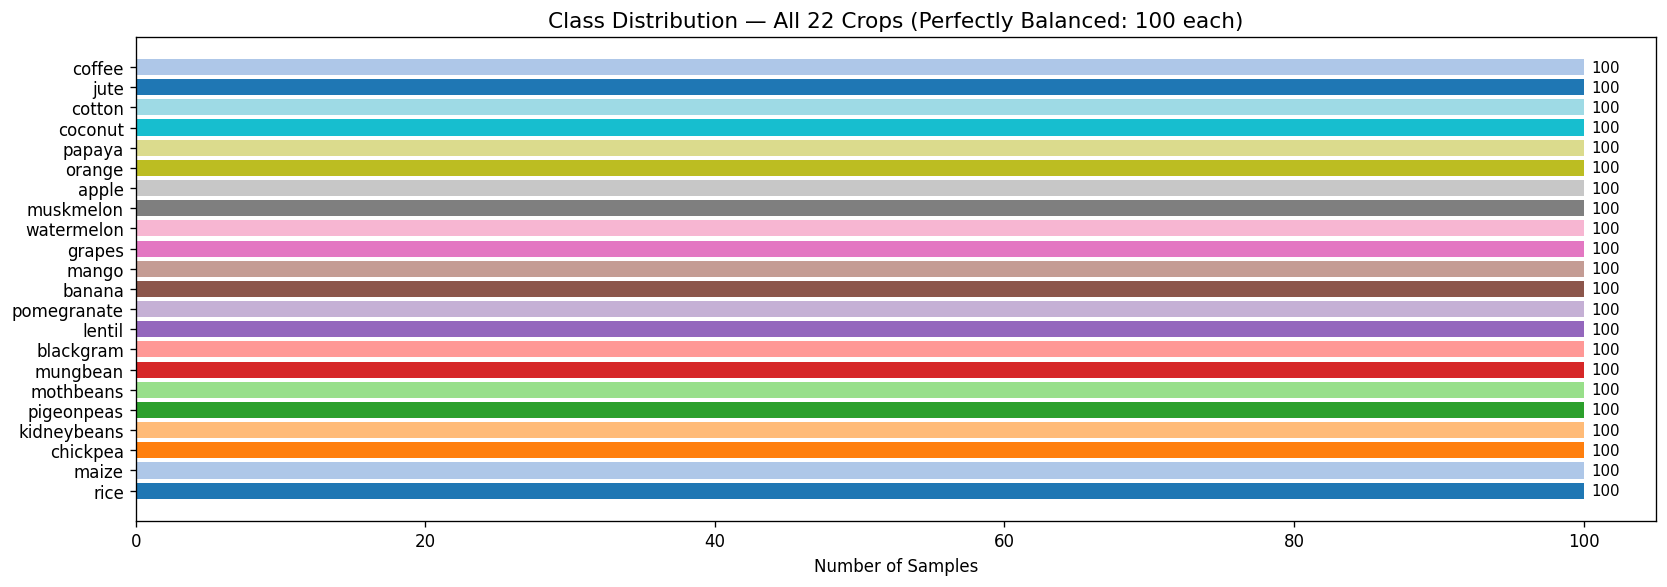

✅ Dataset is perfectly balanced — 100 samples per crop!


In [28]:
# ── 4.1 Class Distribution ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
counts = df['label'].value_counts().sort_values()
bars = ax.barh(counts.index, counts.values, color=plt.cm.tab20.colors)
ax.set_xlabel('Number of Samples')
ax.set_title('Class Distribution — All 22 Crops (Perfectly Balanced: 100 each)', fontsize=13)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
            str(val), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('eda_class_distribution.png', bbox_inches='tight')
plt.show()
print("✅ Dataset is perfectly balanced — 100 samples per crop!")


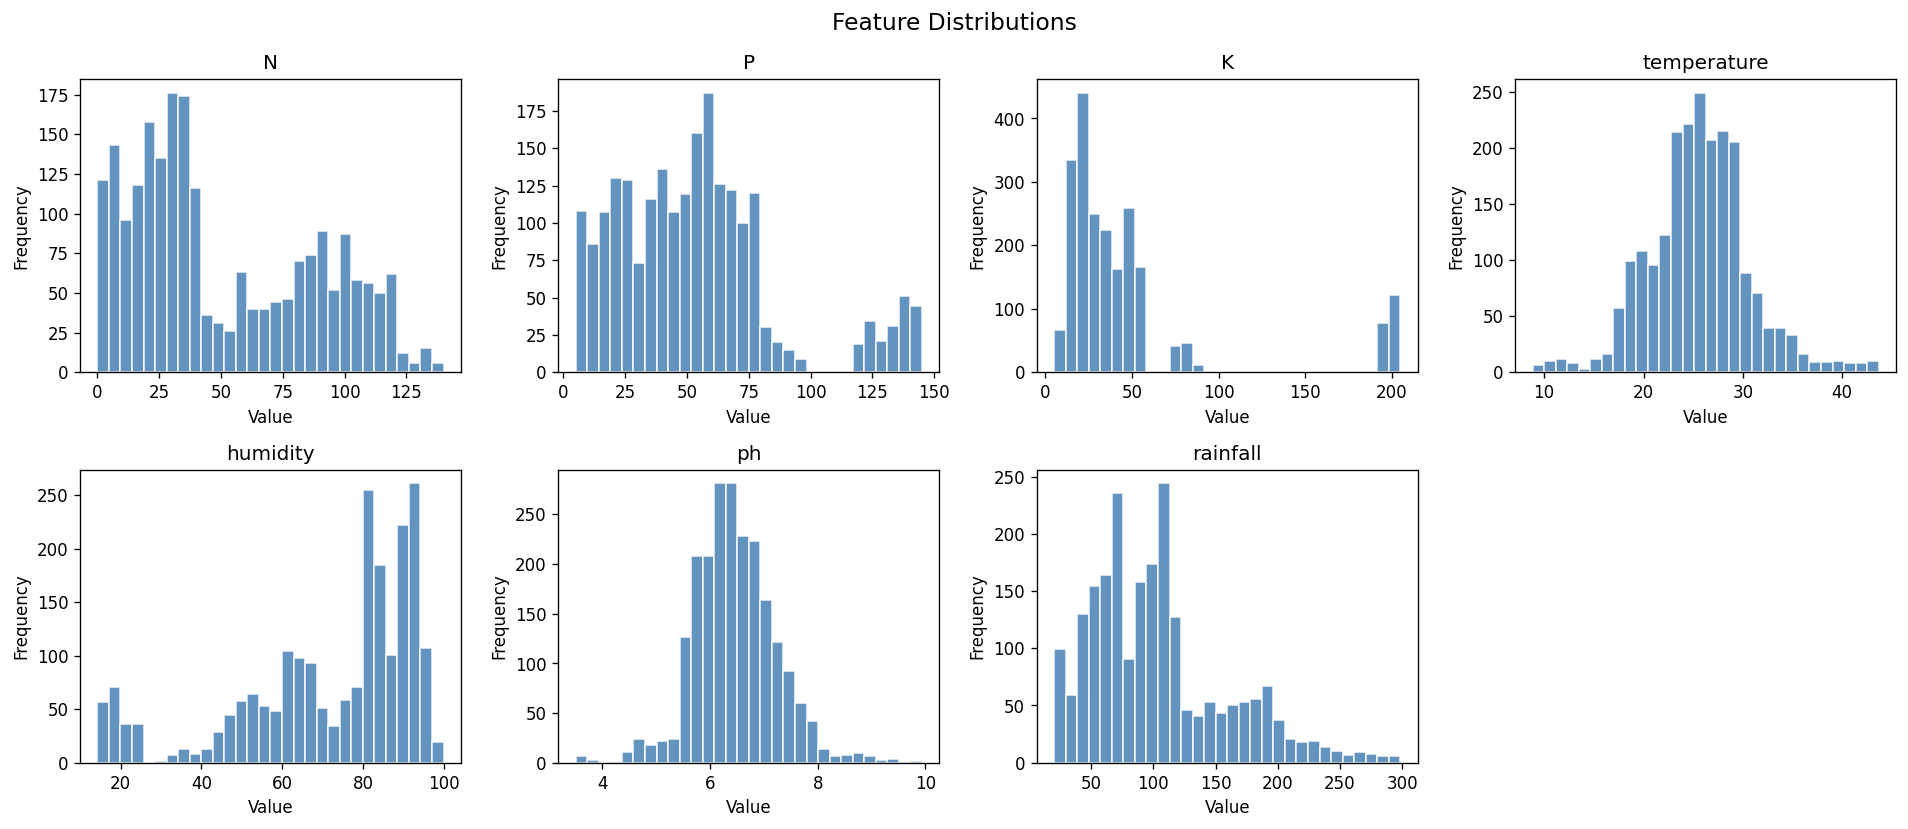

In [29]:
# ── 4.2 Feature Distributions ───────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(features):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
axes[-1].set_visible(False)
plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.savefig('eda_distributions.png', bbox_inches='tight')
plt.show()


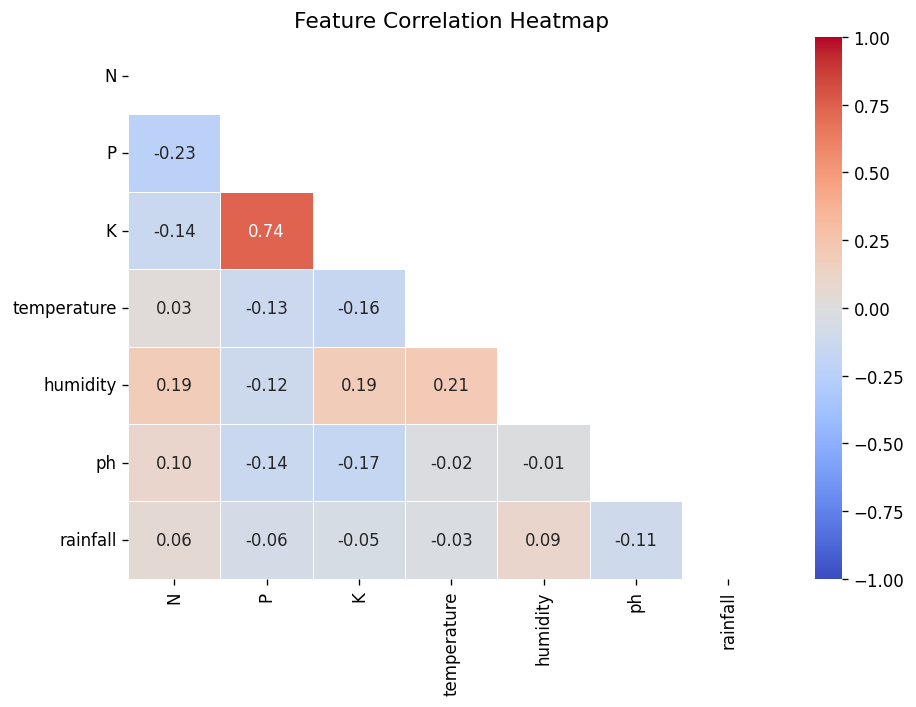

In [30]:
# ── 4.3 Correlation Heatmap ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.savefig('eda_correlation.png', bbox_inches='tight')
plt.show()


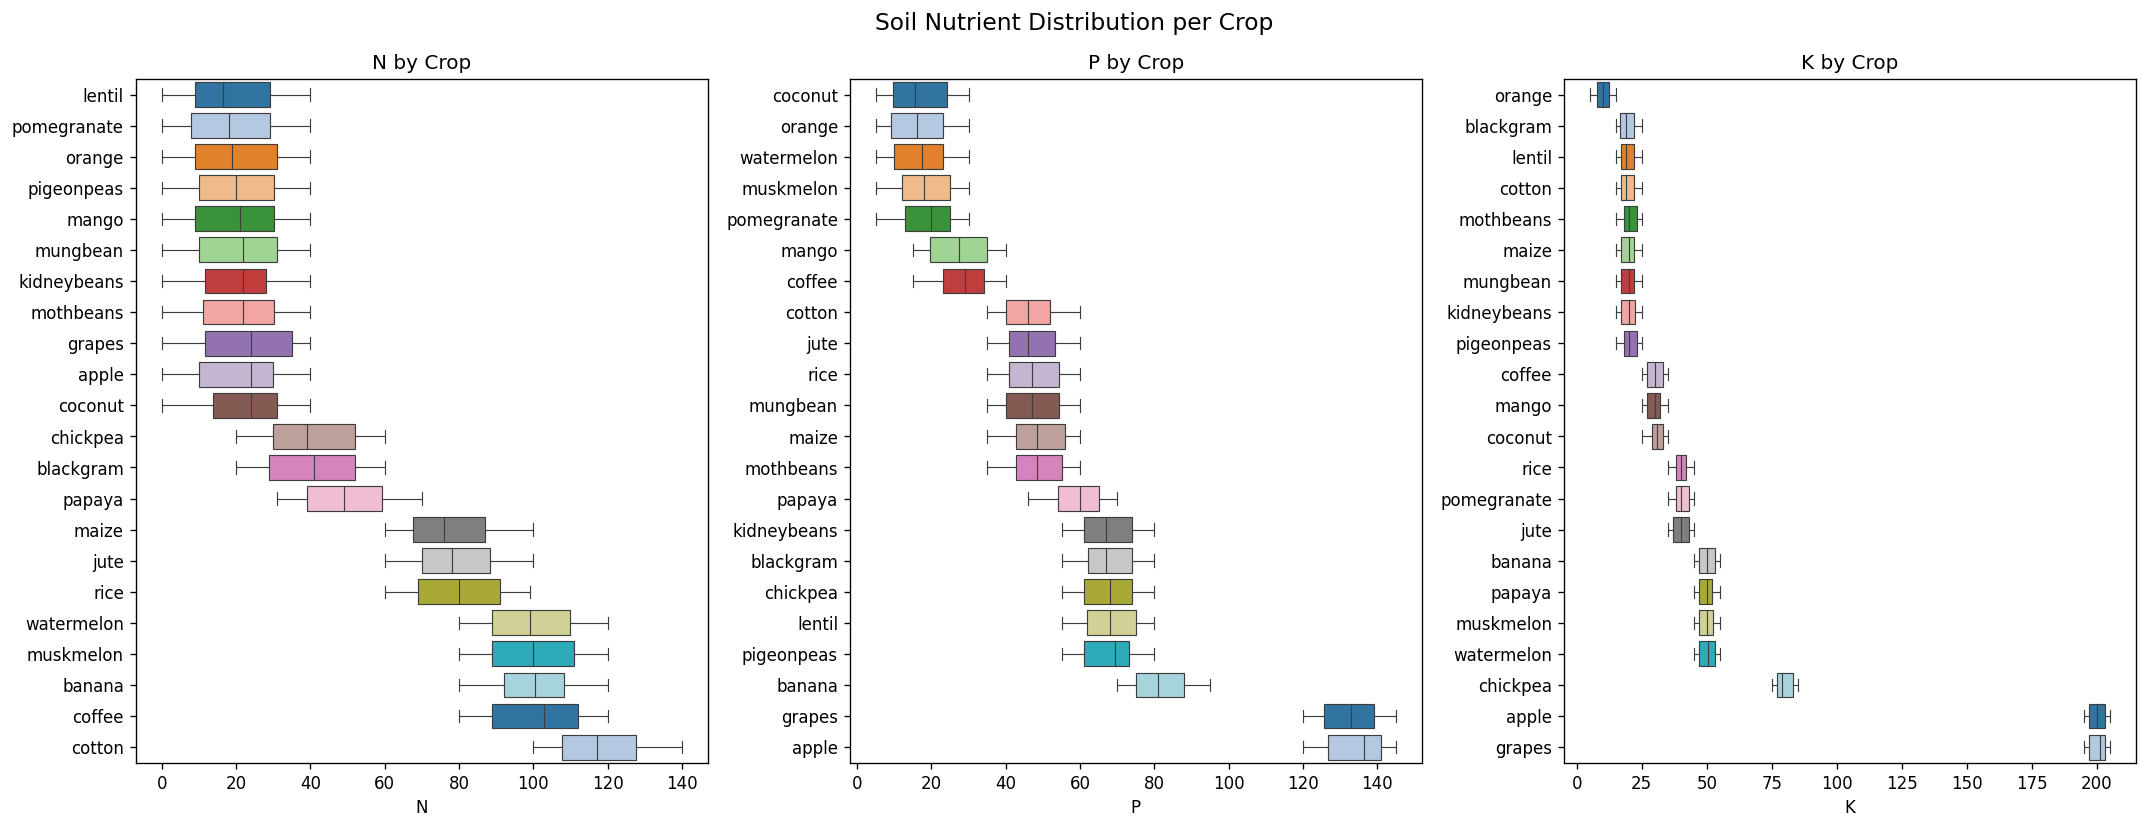

In [31]:
# ── 4.4 Box Plots — N, P, K per Crop ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, col in zip(axes, ['N','P','K']):
    order = df.groupby('label')[col].median().sort_values().index
    sns.boxplot(data=df, x=col, y='label', order=order,
                palette='tab20', ax=ax, linewidth=0.7)
    ax.set_title(f'{col} by Crop', fontsize=12)
    ax.set_ylabel('')
plt.suptitle('Soil Nutrient Distribution per Crop', fontsize=14)
plt.tight_layout()
plt.savefig('eda_npk_boxplots.png', bbox_inches='tight')
plt.show()


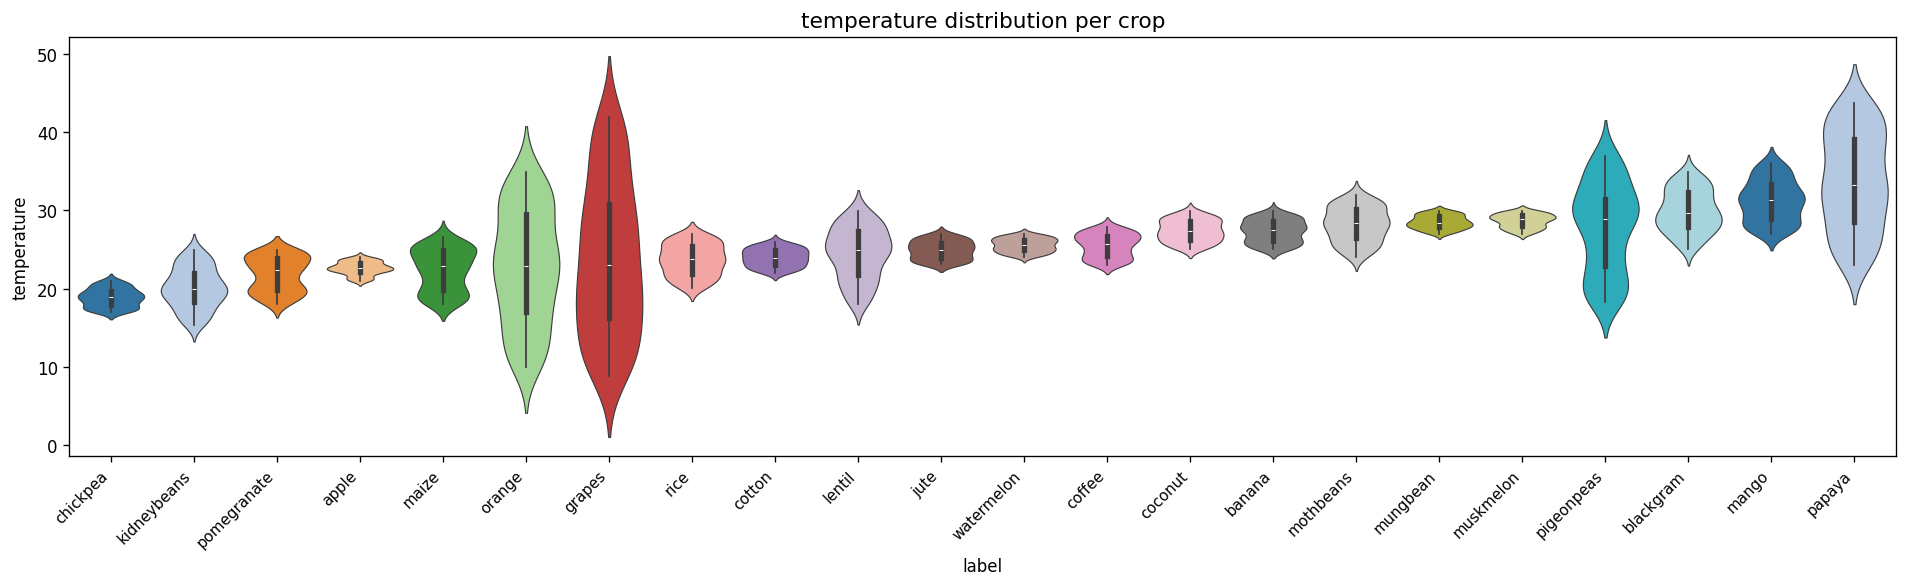

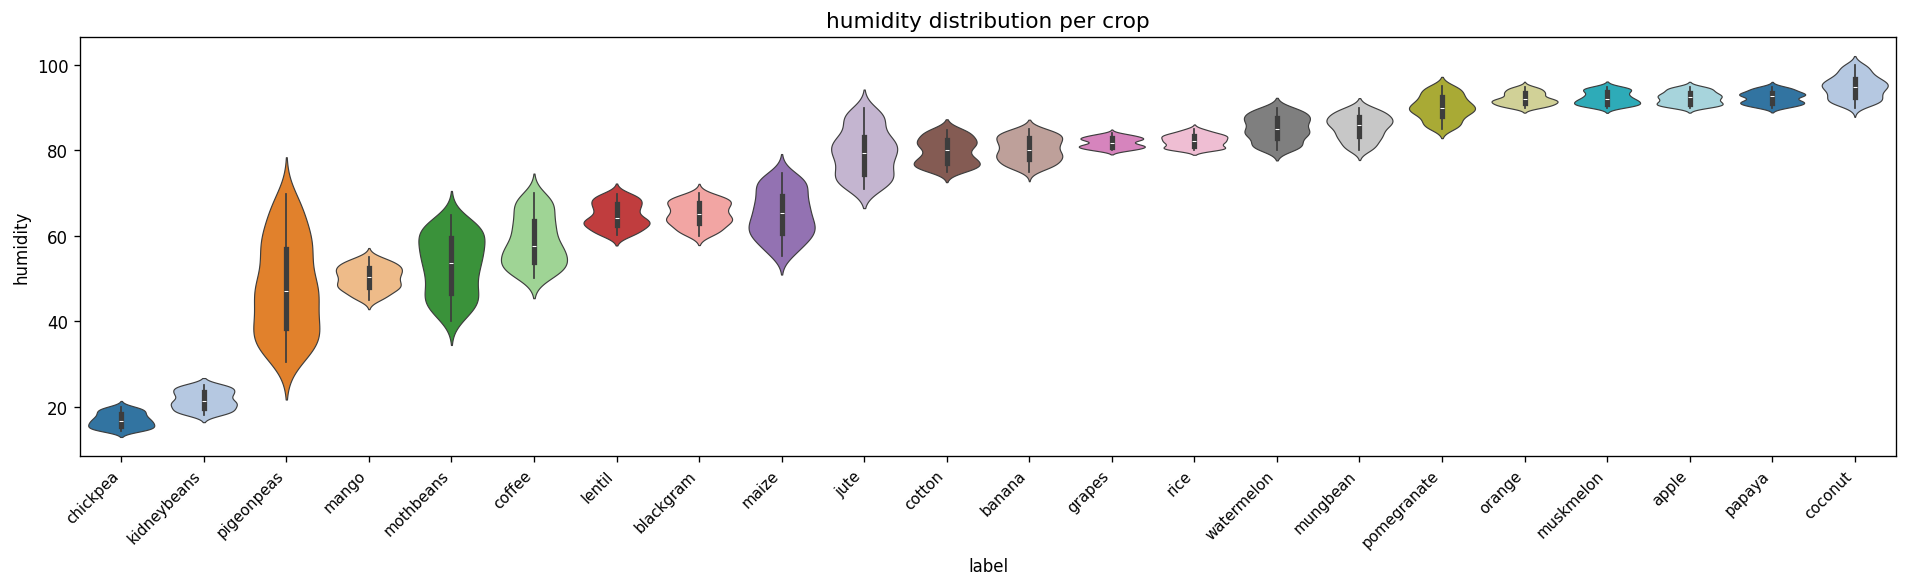

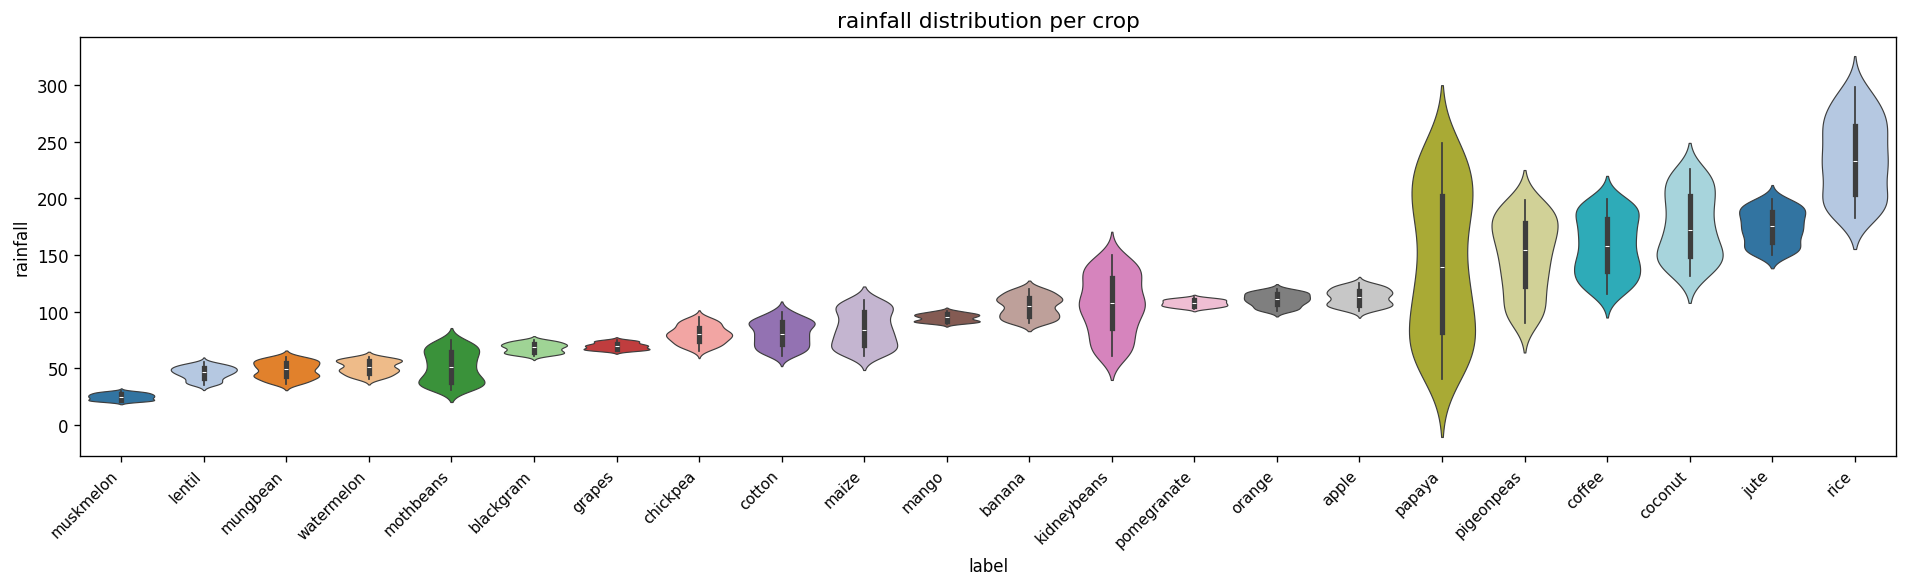

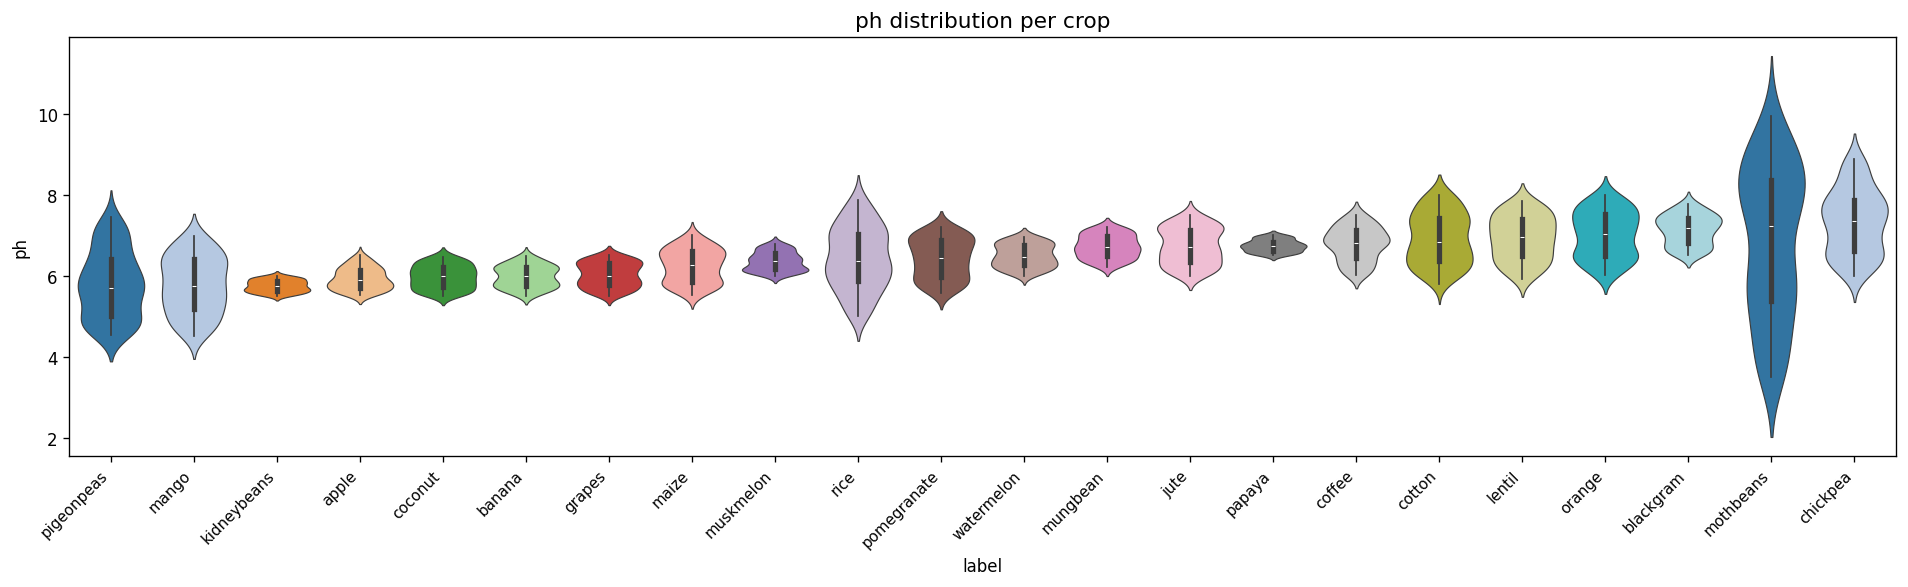

In [32]:
# ── 4.5 Violin Plots — Climate Features ─────────────────────────────────
for col in ['temperature','humidity','rainfall','ph']:
    fig, ax = plt.subplots(figsize=(16, 5))
    order = df.groupby('label')[col].median().sort_values().index
    sns.violinplot(data=df, x='label', y=col, order=order,
                   palette='tab20', ax=ax, linewidth=0.7)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    ax.set_title(f'{col} distribution per crop', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'eda_violin_{col}.png', bbox_inches='tight')
    plt.show()


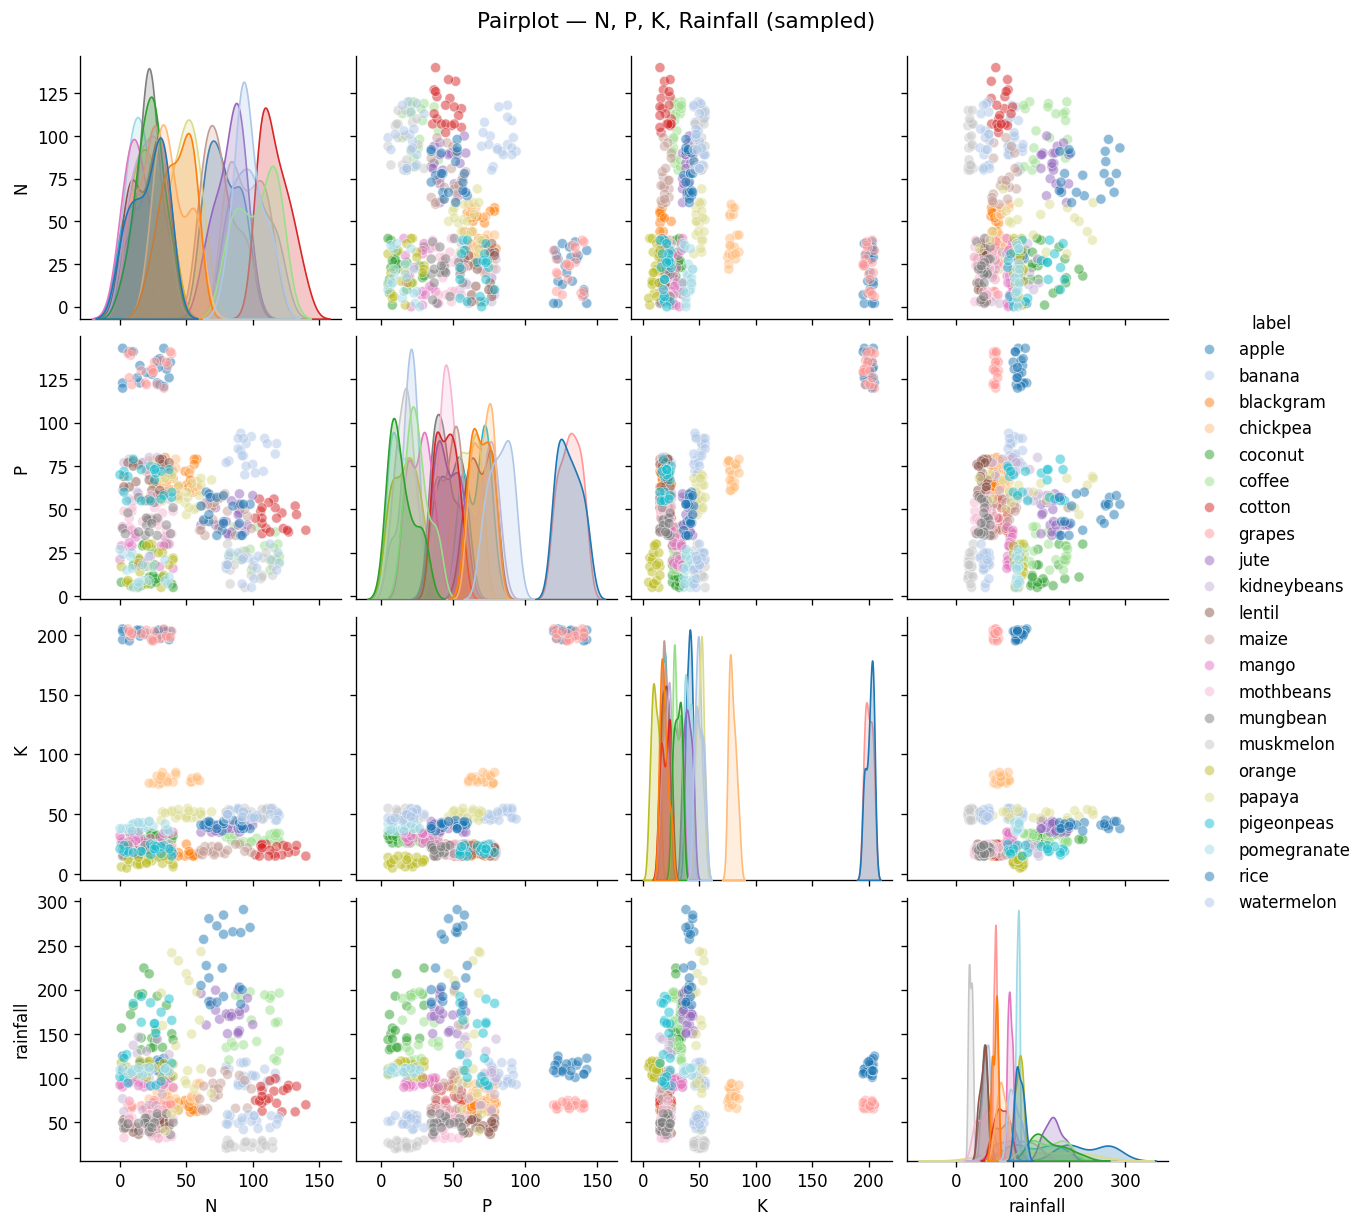

In [33]:
# ── 4.6 Pair Plot ───────────────────────────────────────────────────────
sample_df = df.groupby('label').apply(
    lambda x: x.sample(20, random_state=42)).reset_index(drop=True)
g = sns.pairplot(sample_df[['N','P','K','rainfall','label']],
                 hue='label', palette='tab20',
                 plot_kws={'alpha':0.5}, height=2.5)
g.fig.suptitle('Pairplot — N, P, K, Rainfall (sampled)', y=1.02, fontsize=13)
plt.savefig('eda_pairplot.png', bbox_inches='tight')
plt.show()


Abhitha's note :-EDA reveals strong humidity and rainfall patterns distinguishing crops. P and K show high correlation (0.74) suggesting multicollinearity.

---
## Stage 5 — Feature Engineering & Selection
**Lead: Adithyan** | Issue #5


In [34]:
# ── 5.1 NPK Ratio Features ──────────────────────────────────────────────
df_eng = df.copy()
df_eng['NPK_sum']   = df_eng['N'] + df_eng['P'] + df_eng['K']
df_eng['N_P_ratio'] = df_eng['N'] / (df_eng['P'] + 1)
df_eng['N_K_ratio'] = df_eng['N'] / (df_eng['K'] + 1)

print("Engineered features sample:")
print(df_eng[['N','P','K','NPK_sum','N_P_ratio','N_K_ratio']].head(5).round(3))


Engineered features sample:
    N   P   K  NPK_sum  N_P_ratio  N_K_ratio
0  90  42  43      175      2.093      2.045
1  85  58  41      184      1.441      2.024
2  60  55  44      159      1.071      1.333
3  74  35  40      149      2.056      1.805
4  78  42  42      162      1.814      1.814


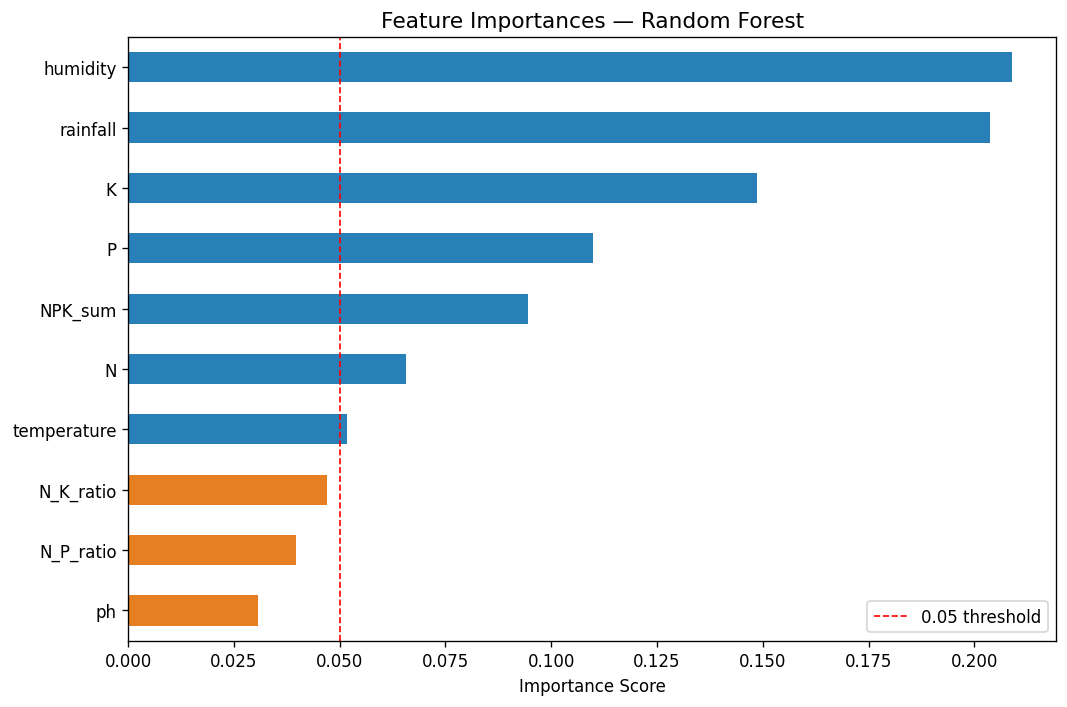


Ranked importances:
humidity       0.2089
rainfall       0.2037
K              0.1485
P              0.1100
NPK_sum        0.0944
N              0.0656
temperature    0.0516
N_K_ratio      0.0470
N_P_ratio      0.0396
ph             0.0307
dtype: float64


In [35]:
# ── 5.2 Feature Importance via Random Forest ────────────────────────────
from sklearn.ensemble import RandomForestClassifier

all_features = features + ['NPK_sum','N_P_ratio','N_K_ratio']
rf_fs = RandomForestClassifier(n_estimators=100, random_state=42)
rf_fs.fit(df_eng[all_features], df['label_encoded'])

importances = pd.Series(
    rf_fs.feature_importances_, index=all_features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#e67e22' if i >= len(features) else '#2980b9'
          for i in range(len(importances))]
importances.plot(kind='barh', ax=ax, color=colors[::-1])
ax.set_title('Feature Importances — Random Forest', fontsize=13)
ax.set_xlabel('Importance Score')
ax.axvline(x=0.05, color='red', linestyle='--', linewidth=1, label='0.05 threshold')
ax.legend()
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

print("\nRanked importances:")
print(importances.sort_values(ascending=False).round(4))


In [36]:
# ── 5.3 SelectKBest ─────────────────────────────────────────────────────
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_train, y_train)
scores = pd.Series(selector.scores_, index=features).sort_values(ascending=False)
print("SelectKBest F-scores:")
print(scores.round(2))
print("\n✅ Decision: use original 7 features.")
print("   Engineered features add marginal value — original features retained.")


SelectKBest F-scores:
K              21755.15
humidity        2465.54
P               1470.45
N                721.63
rainfall         482.18
temperature       81.62
ph                49.65
dtype: float64

✅ Decision: use original 7 features.
   Engineered features add marginal value — original features retained.


---
## Stage 6 — Model Building & Training
**Lead: Adithyan (RF) · Abhita (KNN + DT)** | Issue #6


In [37]:
# ── 6.1 Random Forest ───────────────────────────────────────────────────
from sklearn.model_selection import GridSearchCV

print("Training Random Forest with GridSearchCV...")
rf_params = {
    'n_estimators'    : [100, 200],
    'max_depth'       : [None, 10, 20],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42),
                       rf_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_

print(f"\nBest RF params : {rf_grid.best_params_}")
print(f"Best CV acc    : {rf_grid.best_score_*100:.2f}%")
joblib.dump(rf_best, 'models/random_forest.pkl')
print("✅ Saved to models/random_forest.pkl")


Training Random Forest with GridSearchCV...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best RF params : {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Best CV acc    : 99.60%
✅ Saved to models/random_forest.pkl


In [38]:
# ── 6.2 KNN ─────────────────────────────────────────────────────────────
from sklearn.neighbors import KNeighborsClassifier

print("Training KNN with GridSearchCV...")
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'metric'     : ['euclidean', 'manhattan']
}
knn_grid = GridSearchCV(KNeighborsClassifier(),
                        knn_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
knn_grid.fit(X_train_scaled, y_train)
knn_best = knn_grid.best_estimator_

print(f"\nBest KNN params : {knn_grid.best_params_}")
print(f"Best CV acc     : {knn_grid.best_score_*100:.2f}%")
joblib.dump(knn_best, 'models/knn.pkl')
print("✅ Saved to models/knn.pkl")


Training KNN with GridSearchCV...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best KNN params : {'metric': 'manhattan', 'n_neighbors': 5}
Best CV acc     : 97.90%
✅ Saved to models/knn.pkl


In [39]:
# ── 6.3 Decision Tree ───────────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier

print("Training Decision Tree with GridSearchCV...")
dt_params = {
    'max_depth'        : [5, 10, 15, None],
    'criterion'        : ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10]
}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                       dt_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
dt_grid.fit(X_train, y_train)
dt_best = dt_grid.best_estimator_

print(f"\nBest DT params : {dt_grid.best_params_}")
print(f"Best CV acc    : {dt_grid.best_score_*100:.2f}%")
joblib.dump(dt_best, 'models/decision_tree.pkl')
print("✅ Saved to models/decision_tree.pkl")


Training Decision Tree with GridSearchCV...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best DT params : {'criterion': 'gini', 'max_depth': 15, 'min_samples_split': 5}
Best CV acc    : 98.58%
✅ Saved to models/decision_tree.pkl


---
## Stage 7 — Model Evaluation & Comparison
**Lead: Abhitha** | Issue #7


In [40]:
# ── 7.1 Test Accuracy Comparison ────────────────────────────────────────
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_rf  = rf_best.predict(X_test)
y_pred_knn = knn_best.predict(X_test_scaled)
y_pred_dt  = dt_best.predict(X_test)

results = {
    'Random Forest': accuracy_score(y_test, y_pred_rf),
    'KNN'          : accuracy_score(y_test, y_pred_knn),
    'Decision Tree': accuracy_score(y_test, y_pred_dt)
}

print("=" * 40)
print(f"{'Model':<20} {'Test Accuracy':>13}")
print("=" * 40)
for model, acc in sorted(results.items(), key=lambda x: -x[1]):
    print(f"{model:<20} {acc*100:>12.2f}%")
print("=" * 40)


Model                Test Accuracy
Random Forest               99.55%
Decision Tree               98.18%
KNN                         97.73%


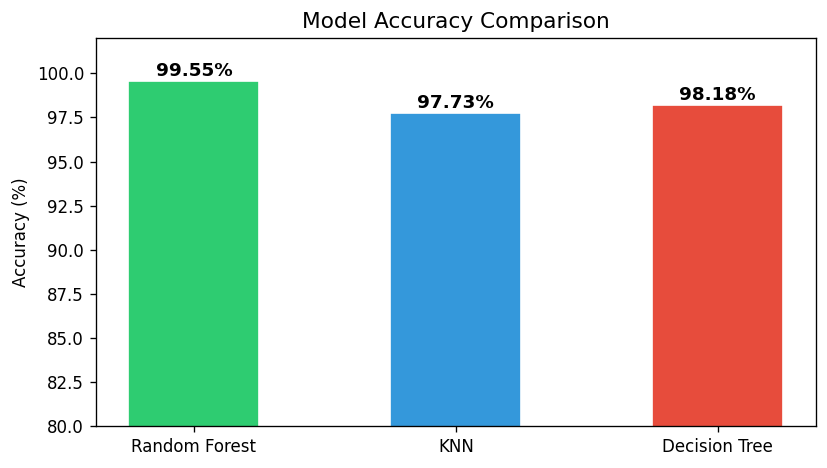

In [41]:
# ── 7.2 Accuracy Bar Chart ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#2ecc71','#3498db','#e74c3c']
bars = ax.bar(list(results.keys()),
              [v*100 for v in results.values()],
              color=colors, width=0.5, edgecolor='white')
ax.set_ylim(80, 102)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Accuracy Comparison', fontsize=13)
for bar, acc in zip(bars, [v*100 for v in results.values()]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{acc:.2f}%', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()


In [42]:
# ── 7.3 Classification Report ───────────────────────────────────────────
print("Classification Report — Random Forest (Best Model):")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))


Classification Report — Random Forest (Best Model):
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      

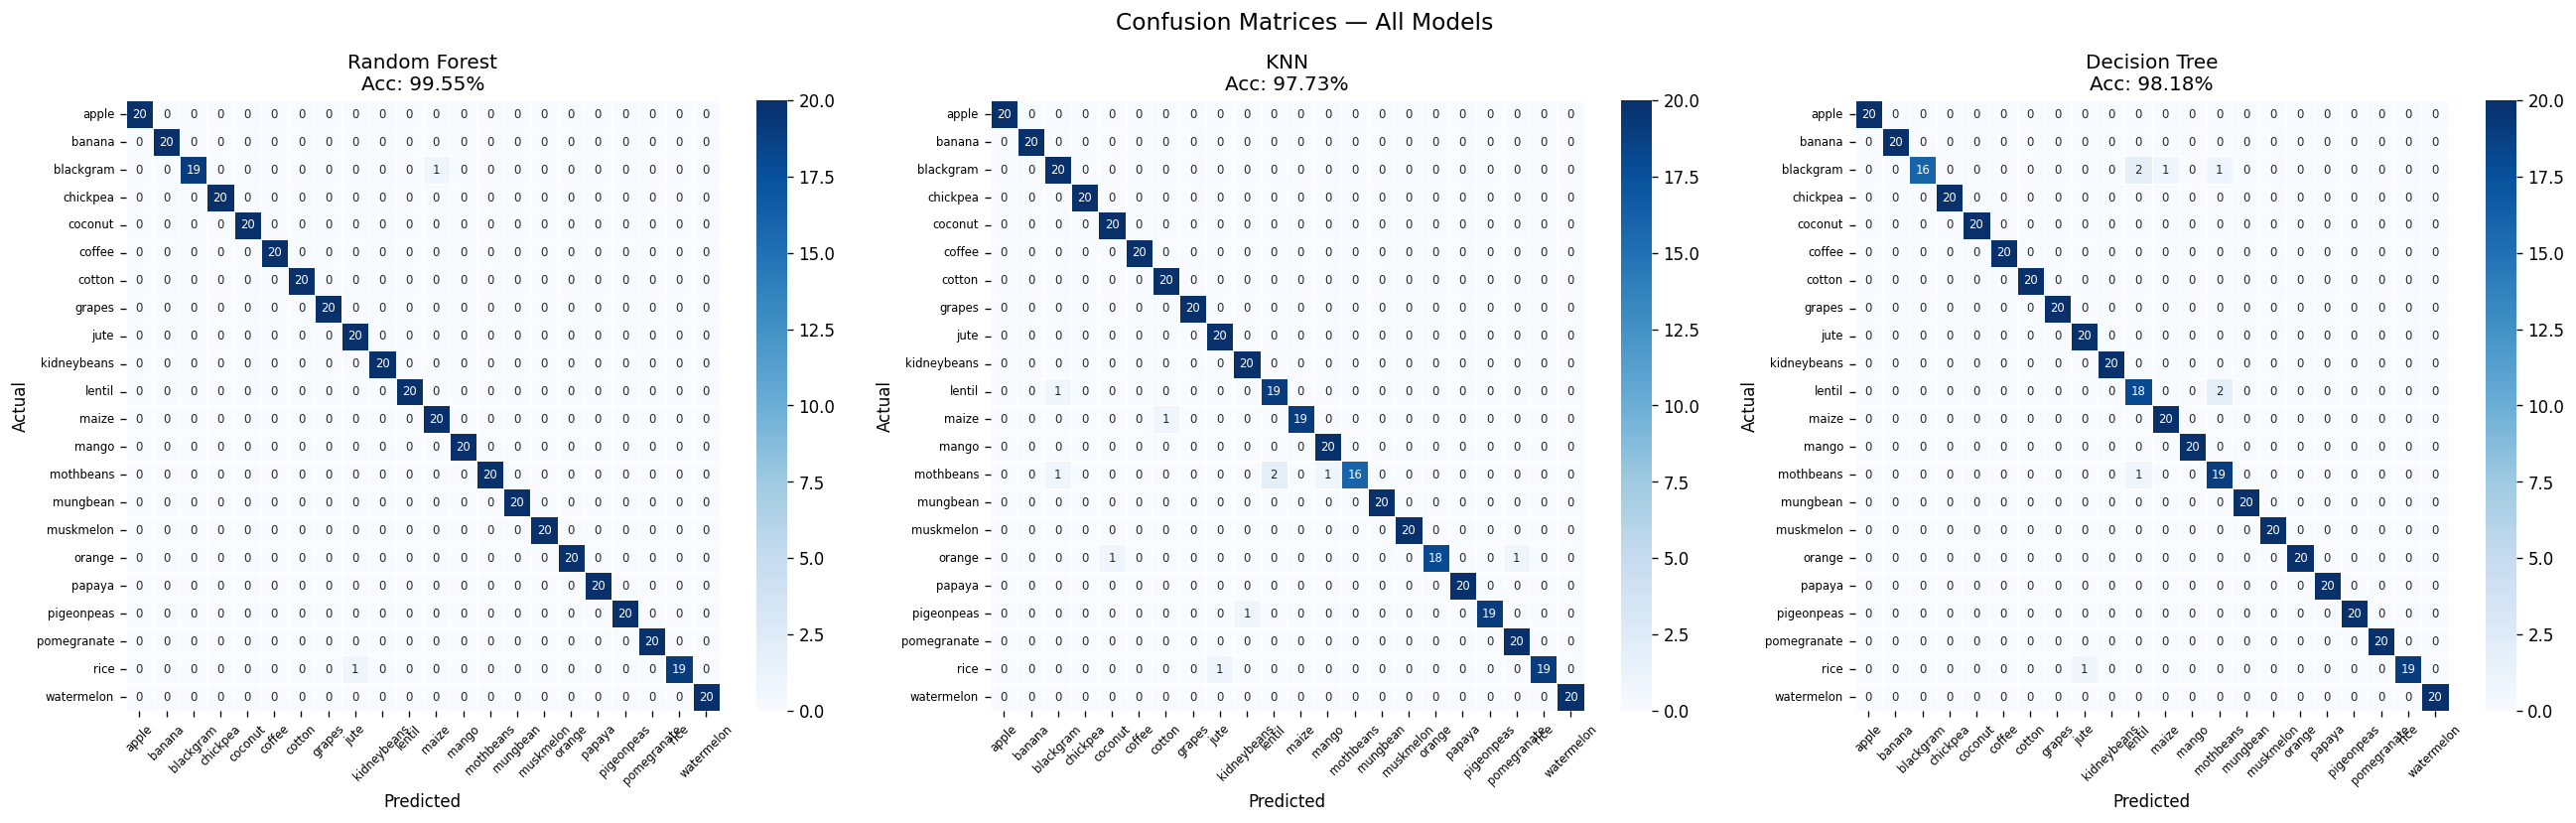

In [43]:
# ── 7.4 Confusion Matrices ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
for ax, (name, y_pred) in zip(axes, [
    ('Random Forest', y_pred_rf),
    ('KNN', y_pred_knn),
    ('Decision Tree', y_pred_dt)
]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_,
                linewidths=0.3, annot_kws={'size':7})
    ax.set_title(f'{name}\nAcc: {results[name]*100:.2f}%', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0,  labelsize=7)
plt.suptitle('Confusion Matrices — All Models', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()


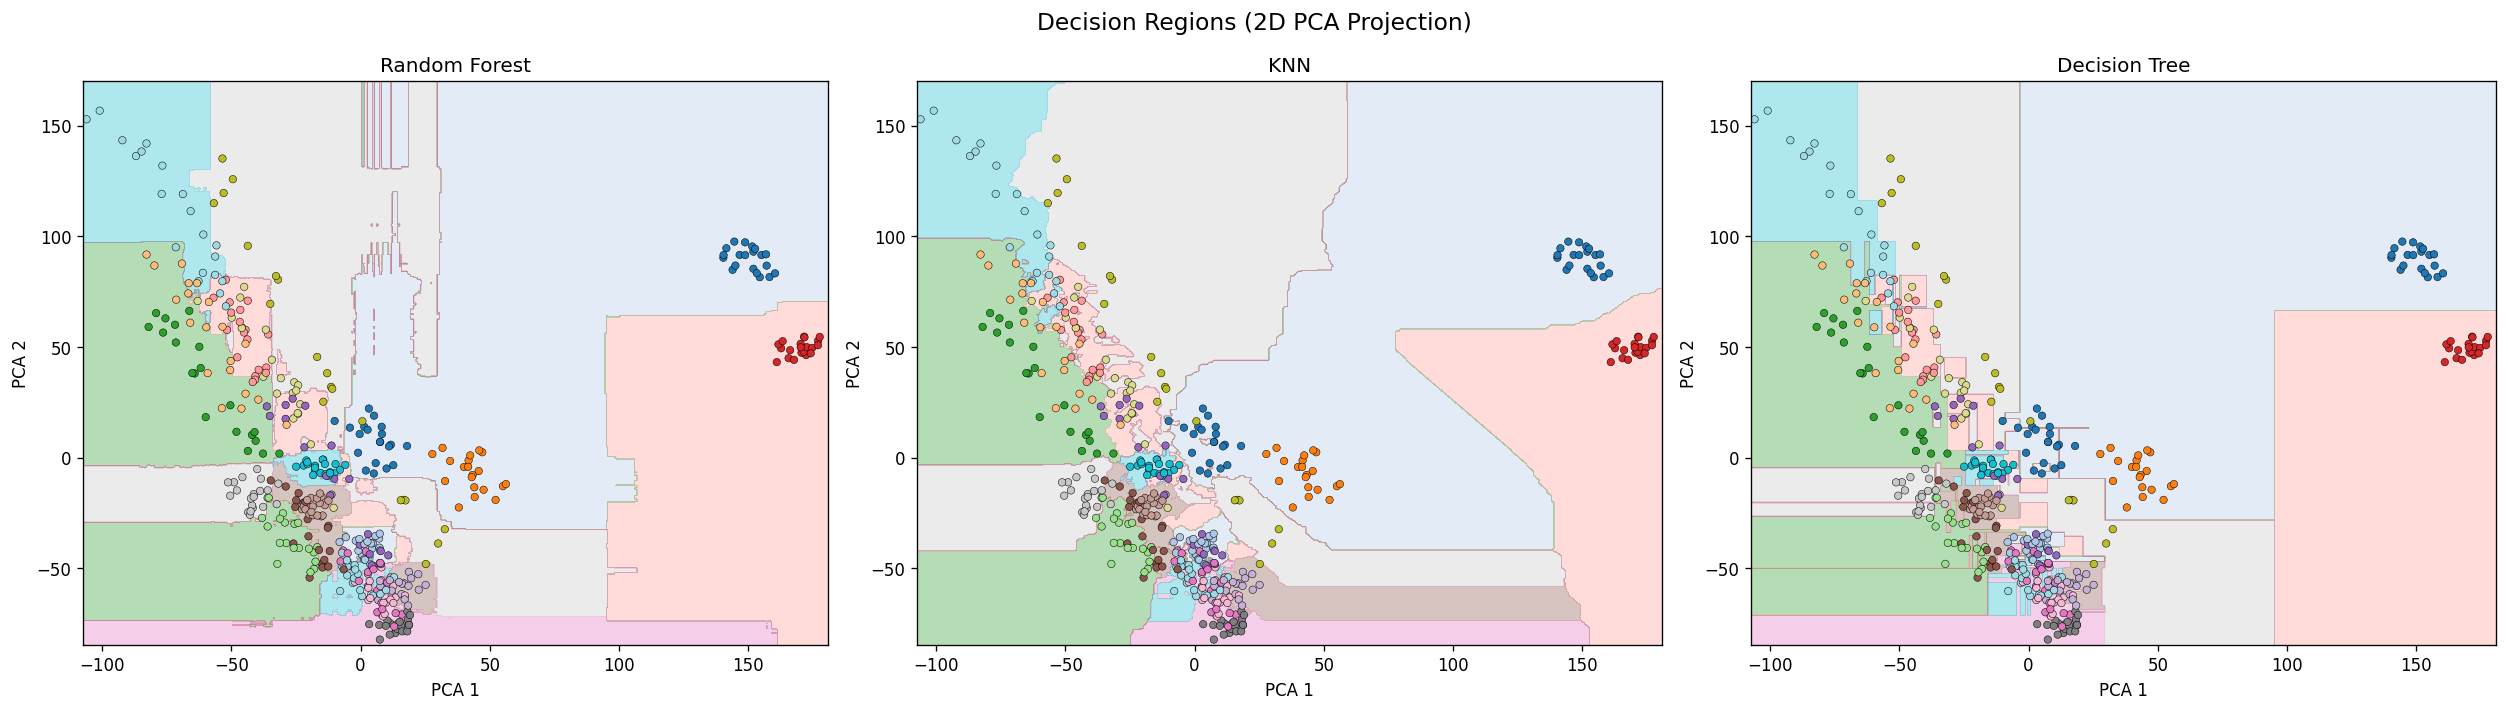

In [44]:
# ── 7.5 Decision Region Plot (PCA) ──────────────────────────────────────
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap

pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train)
X_test_2d  = pca.transform(X_test)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
cmap = ListedColormap(plt.cm.tab20.colors[:22])
h = 0.3

for ax, (name, model_2d) in zip(axes, [
    ('Random Forest', RandomForestClassifier(**rf_grid.best_params_, random_state=42)),
    ('KNN',           KNeighborsClassifier(**knn_grid.best_params_)),
    ('Decision Tree', DecisionTreeClassifier(**dt_grid.best_params_, random_state=42))
]):
    model_2d.fit(X_train_2d, y_train)
    x_min, x_max = X_train_2d[:,0].min()-1, X_train_2d[:,0].max()+1
    y_min, y_max = X_train_2d[:,1].min()-1, X_train_2d[:,1].max()+1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.35, cmap=cmap)
    ax.scatter(X_test_2d[:,0], X_test_2d[:,1],
               c=y_test, cmap=cmap, edgecolor='k', s=20, linewidth=0.3)
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('PCA 1')
    ax.set_ylabel('PCA 2')

plt.suptitle('Decision Regions (2D PCA Projection)', fontsize=14)
plt.tight_layout()
plt.savefig('decision_regions.png', bbox_inches='tight')
plt.show()


Abhitha's note:- Random Forest achieves highest test accuracy of 99.55%. Confusion matrix shows near-perfect classification across all 22 crops.

---
## Stage 8 — Model Interpretation & Explainability
**Lead: Abhitha** | Issue #8


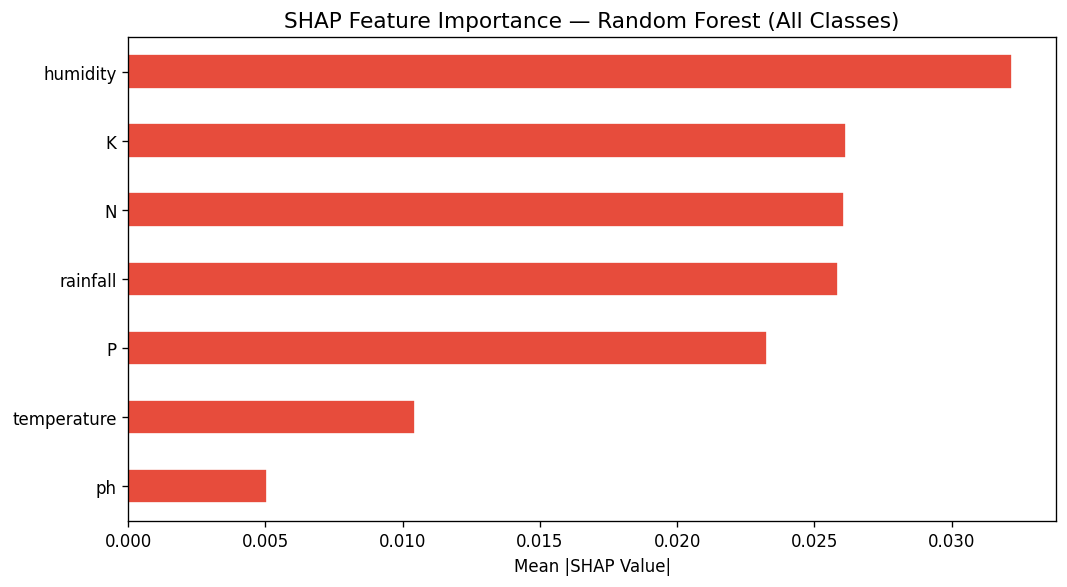

✅ SHAP summary done!


In [45]:
import shap
import numpy as np

explainer   = shap.TreeExplainer(rf_best)
shap_values = explainer.shap_values(X_test)

# Average SHAP values across all classes
shap_mean = np.abs(shap_values).mean(axis=2) if len(np.array(shap_values).shape) == 3 else np.abs(shap_values).mean(axis=0)

# Plot mean importance per feature
shap_importance = pd.Series(shap_mean.mean(axis=0), index=features).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
shap_importance.plot(kind='barh', color='#e74c3c', ax=ax, edgecolor='white')
ax.set_title('SHAP Feature Importance — Random Forest (All Classes)', fontsize=13)
ax.set_xlabel('Mean |SHAP Value|')
plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight')
plt.show()
print("✅ SHAP summary done!")

Sample input:
       N   P  K  temperature  humidity        ph   rainfall
1609  13  23  6    23.961476  90.26408  7.365338  102.69587

Predicted crop: orange


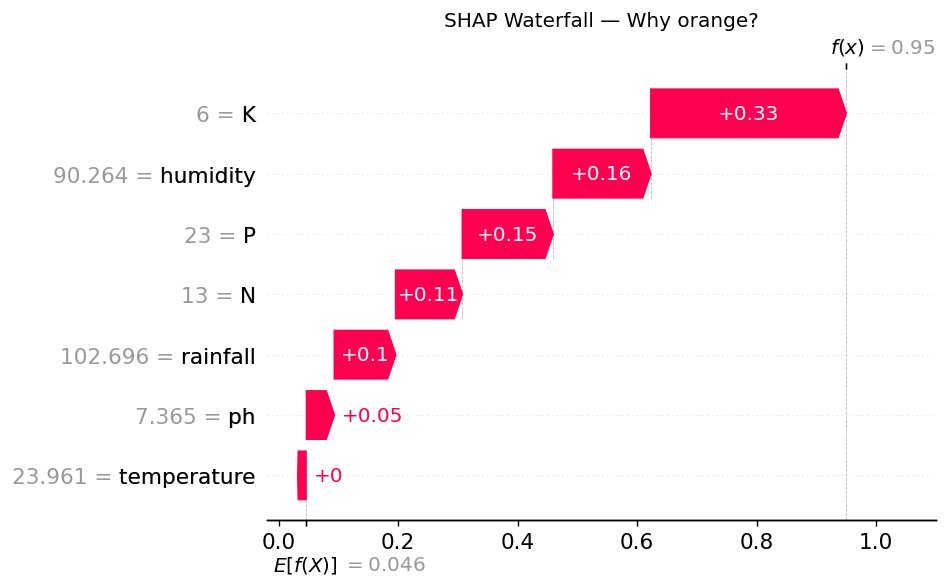

In [46]:
# ── 8.2 SHAP Waterfall — Single Sample ──────────────────────────────────
sample_idx       = 0
sample           = X_test.iloc[[sample_idx]]
pred_class_idx   = rf_best.predict(sample)[0]
pred_crop        = le.inverse_transform([pred_class_idx])[0]

print(f"Sample input:\n{sample.to_string()}")
print(f"\nPredicted crop: {pred_crop}")

shap_exp = shap.TreeExplainer(rf_best)(sample)
shap.waterfall_plot(shap_exp[0, :, pred_class_idx], max_display=7, show=False)
plt.title(f'SHAP Waterfall — Why {pred_crop}?', fontsize=12)
plt.tight_layout()
plt.savefig('shap_waterfall.png', bbox_inches='tight')
plt.show()


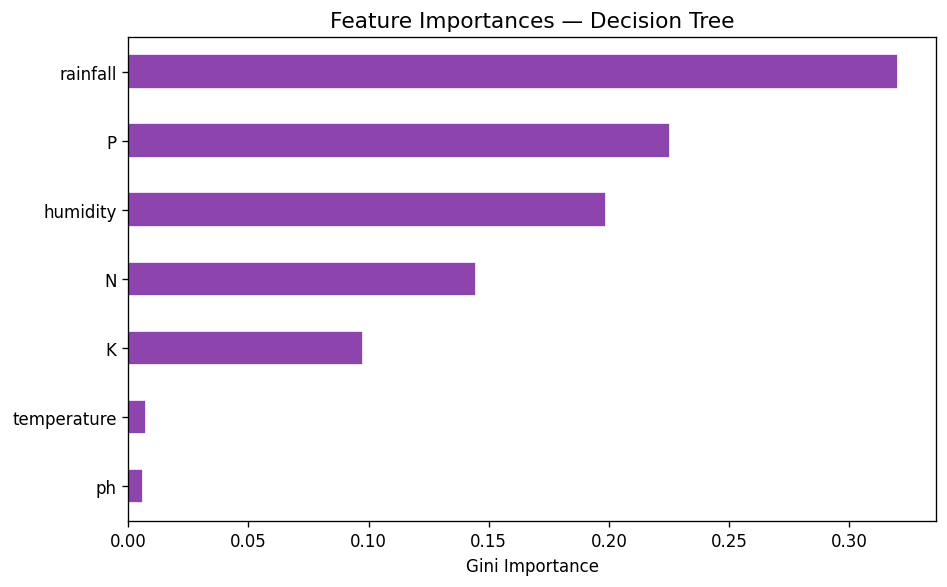

In [47]:
# ── 8.3 Decision Tree Feature Importance ────────────────────────────────
dt_imp = pd.Series(dt_best.feature_importances_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
dt_imp.plot(kind='barh', color='#8e44ad', ax=ax, edgecolor='white')
ax.set_title('Feature Importances — Decision Tree', fontsize=13)
ax.set_xlabel('Gini Importance')
plt.tight_layout()
plt.savefig('dt_feature_importance.png', bbox_inches='tight')
plt.show()


Abhitha's note:-SHAP analysis confirms humidity as the most influential feature globally. Waterfall plot shows K drives orange prediction most strongly.